In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import mlflow
import mlflow.lightgbm
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from itertools import product

warnings.filterwarnings('ignore')

TARGET= 'consommation_telerelevee_hta'

OTHERS= [
    'consommation_telerelevee_btsup',
    'consommation_telerelevee_professionnelle',
    'consommation_telerelevee_residentielle',
]

HORIZON=7*48

In [2]:
df=pd.read_csv("C:/Users/T14s/Desktop/ml-project/data/features_with_lags.csv",parse_dates=['datetime'])
df = df.set_index('datetime')

In [3]:
featurs_col=['year_utc', 'month_utc', 'day', 'day_of_week', 'est_weekend',
       'est_ferie', 'hour_utc', 'minute_utc', 'temperature_reelle_lissee',
       'temperature_normale_lissee', 'ecart_temperature', 'temp_x_weekend',
       'temp_x_ferier', 'degre_jour_chauffage', 'degre_jour_clim','jour_fetes',
       'pseudo_rayonnement','consommation_telerelevee_hta_lag_336',
       'consommation_telerelevee_hta_lag_672',
       'consommation_telerelevee_hta_lag_1344',]
target='consommation_telerelevee_hta'

In [4]:
X=df[featurs_col]
y=df[target]

In [5]:
X_train_full= X.iloc[:-HORIZON]  
X_test= X.iloc[-HORIZON:]   
y_train_full= y.iloc[:-HORIZON]
y_test= y.iloc[-HORIZON:]

In [6]:

print('Features finales :', featurs_col)
print('Nombre :', len(featurs_col))

X_train_final= X_train_full[featurs_col]
X_test_final= X_test[featurs_col]

Features finales : ['year_utc', 'month_utc', 'day', 'day_of_week', 'est_weekend', 'est_ferie', 'hour_utc', 'minute_utc', 'temperature_reelle_lissee', 'temperature_normale_lissee', 'ecart_temperature', 'temp_x_weekend', 'temp_x_ferier', 'degre_jour_chauffage', 'degre_jour_clim', 'jour_fetes', 'pseudo_rayonnement', 'consommation_telerelevee_hta_lag_336', 'consommation_telerelevee_hta_lag_672', 'consommation_telerelevee_hta_lag_1344']
Nombre : 20


In [ ]:
PARAM_GRID = {
    'n_estimators': [700, 800],
    'max_depth': [7, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'num_leaves': [63, 81],
}

keys= list(PARAM_GRID.keys())
values= list(PARAM_GRID.values())
combinations= [dict(zip(keys, v)) for v in product(*values)]

tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=HORIZON 
)

mlflow.set_tracking_uri("http://127.0.0.1:5000")

mlflow.set_experiment('LightGBM_HTA01')

best_mae= float('inf')
best_params= None
results= []

for i, params in enumerate(combinations):

    fold_maes= []
    fold_rmses= []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_final)):

        X_cv_train= X_train_final.iloc[train_idx]
        y_cv_train= y_train_full.iloc[train_idx]
        X_cv_val= X_train_final.iloc[val_idx]
        y_cv_val= y_train_full.iloc[val_idx]

        model = LGBMRegressor(
            **params,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )
        model.fit(
            X_cv_train, y_cv_train,
            eval_set=[(X_cv_val, y_cv_val)]
        )

        preds = model.predict(X_cv_val)
        fold_maes.append(mean_absolute_error(y_cv_val, preds))
        fold_rmses.append(np.sqrt(mean_squared_error(y_cv_val, preds)))

    mae_mean  = np.mean(fold_maes)
    mae_std   = np.std(fold_maes)
    rmse_mean = np.mean(fold_rmses)

    results.append({**params, 'mae_mean': mae_mean, 'mae_std': mae_std})

    with mlflow.start_run(run_name=f'run_{i+1:02d}'):
        mlflow.log_params(params)
        mlflow.log_param('target', TARGET)
        mlflow.log_param('n_features_selected', len(featurs_col))
        mlflow.log_param('horizon', 'J+7')

        mlflow.log_metric('cv_mae_mean', mae_mean)
        mlflow.log_metric('cv_mae_std', mae_std)
        mlflow.log_metric('cv_rmse_mean', rmse_mean)

        for f, m in enumerate(fold_maes):
            mlflow.log_metric(f'fold_{f+1}_mae', m)

    if mae_mean < best_mae:
        best_mae= mae_mean
        best_params= params

    print(f'  [{i+1:2d}/{len(combinations)}] MAE={mae_mean:.2f} ± {mae_std:.2f} | {params}')

print(f'\nGrid Search terminé')
print(f'Meilleurs paramètres: {best_params}')
print(f'Meilleure MAE CV: {best_mae:.2f}')


🏃 View run run_01 at: http://127.0.0.1:5000/#/experiments/6/runs/2dd9bd0b4fbd4fb085bd086d9a0236c4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
  [ 1/32] MAE=264712985.18 ± 52297714.90 | {'n_estimators': 700, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'num_leaves': 81}
🏃 View run run_02 at: http://127.0.0.1:5000/#/experiments/6/runs/8997c080255a426c995b517671b20739
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
  [ 2/32] MAE=264712985.18 ± 52297714.90 | {'n_estimators': 700, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'num_leaves': 92}
🏃 View run run_03 at: http://127.0.0.1:5000/#/experiments/6/runs/11123e2bcbf248459860dc517a5b31d9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
  [ 3/32] MAE=264712985.18 ± 52297714.90 | {'n_estimators': 700, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 1.0, 'num_leaves': 81}
🏃 View run run_04 at: http://127.0.0.1:5000/#/experiments/6/runs/ce77902d8dc547b2b06ec345e3e45816
🧪 View e

2026/04/14 19:16:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MAE: 293,713,286
RMSE: 377,804,583
MAPE: 3.00%
R2: 0.9072


2026/04/14 19:16:11 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run FINAL_best_model at: http://127.0.0.1:5000/#/experiments/6/runs/414667c2d4b74af4b1976300303585fd
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6


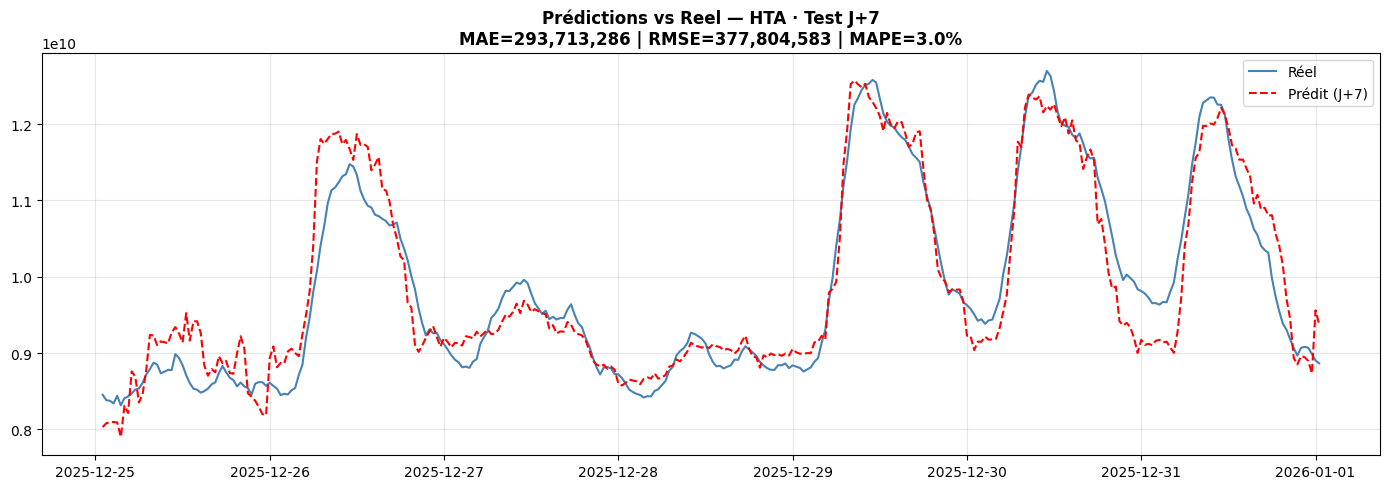

In [22]:
final_model = LGBMRegressor(**best_params, random_state=42, n_jobs=-1, verbose=-1)
final_model.fit(X_train_final, y_train_full)

y_pred= final_model.predict(X_test_final)
y_true_arr = np.array(y_test).flatten()
y_pred_arr = np.array(y_pred).flatten()

mae= mean_absolute_error(y_true_arr, y_pred_arr)
rmse= np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))
mape= np.mean(np.abs((y_true_arr - y_pred_arr) / y_true_arr)) * 100
r2= r2_score(y_true_arr, y_pred_arr)

print(f'MAE: {mae:,.0f}')
print(f'RMSE: {rmse:,.0f}')
print(f'MAPE: {mape:.2f}%')
print(f'R2: {r2:.4f}')

with mlflow.start_run(run_name='FINAL_best_model'):
    mlflow.log_params(best_params)
    mlflow.log_param('target', TARGET)
    mlflow.log_param('n_features_selected', len(featurs_col))
    mlflow.log_param('features_selected', str(featurs_col))
    mlflow.log_param('horizon', 'J+7')

    mlflow.log_metric('test_mae', mae)
    mlflow.log_metric('test_rmse', rmse)
    mlflow.log_metric('test_mape', mape)
    mlflow.log_metric('cv_mae_best', best_mae)

    mlflow.lightgbm.log_model(final_model, 'model')



fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y_test.index, y_test.values, 
        label='Réel', color='steelblue', linewidth=1.5)
ax.plot(y_test.index, y_pred, 
        label='Prédit (J+7)', color='red', linewidth=1.5, linestyle='--')

ax.set_title(f'Prédictions vs Reel — HTA · Test J+7\n'
             f'MAE={mae:,.0f} | RMSE={rmse:,.0f} | MAPE={mape:.1f}%',
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

MAE: 268,207,139
RMSE: 348,425,967
MAPE: 2.74%
R2: 0.9211


2026/04/14 19:05:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/14 19:05:37 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run FINAL_best_model at: http://127.0.0.1:5000/#/experiments/6/runs/8ab21b78ad8f44a485fa0f57bfed2f98
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6


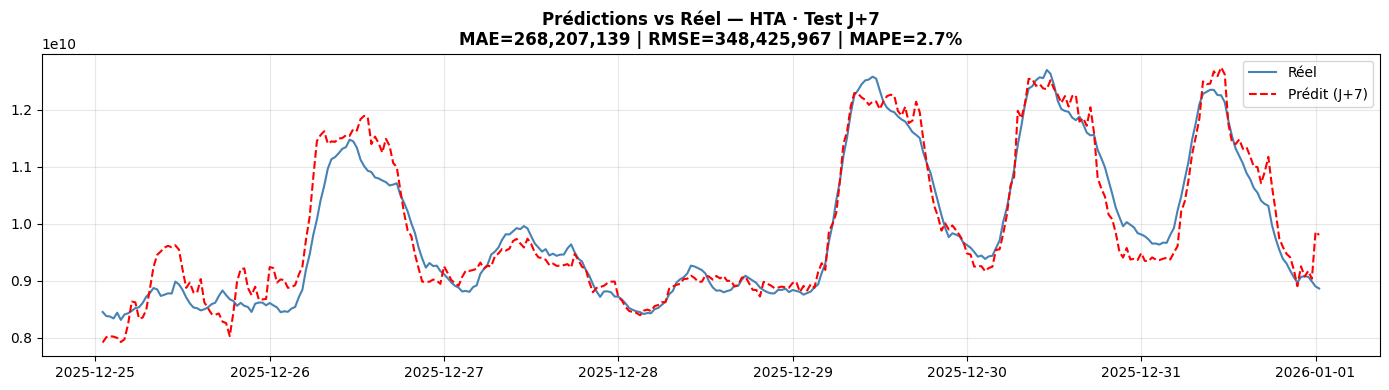

Registered model 'Enedis_HTA_LGB' already exists. Creating a new version of this model...
2026/04/14 19:05:42 WARNING mlflow.tracking._model_registry.fluent: Run with id 8ab21b78ad8f44a485fa0f57bfed2f98 has no artifacts at artifact path 'model', registering model based on models:/m-64cad92650e140fb911deb29e5771ead instead


🏃 View run FINAL_best_model at: http://127.0.0.1:5000/#/experiments/6/runs/8ab21b78ad8f44a485fa0f57bfed2f98
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6


2026/04/14 19:05:42 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Enedis_HTA_LGB, version 4
Created version '4' of model 'Enedis_HTA_LGB'.


<ModelVersion: aliases=[], creation_timestamp=1776189942127, current_stage='Production', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1776189942210, metrics=None, model_id=None, name='Enedis_HTA_LGB', params=None, run_id='8ab21b78ad8f44a485fa0f57bfed2f98', run_link='', source='models:/m-64cad92650e140fb911deb29e5771ead', status='READY', status_message=None, tags={}, user_id='', version='4', workspace='default'>

In [20]:
from mlflow.models.signature import infer_signature
from mlflow.tracking import MlflowClient

final_model = LGBMRegressor(**best_params, random_state=42, n_jobs=-1, verbose=-1)
final_model.fit(X_train_final, y_train_full)

y_pred= final_model.predict(X_test_final)
y_true_arr = np.array(y_test).flatten()
y_pred_arr = np.array(y_pred).flatten()

mae= mean_absolute_error(y_true_arr, y_pred_arr)
rmse= np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))
mape= np.mean(np.abs((y_true_arr - y_pred_arr) / y_true_arr)) * 100
r2= r2_score(y_true_arr, y_pred_arr)

print(f'MAE: {mae:,.0f}')
print(f'RMSE: {rmse:,.0f}')
print(f'MAPE: {mape:.2f}%')
print(f'R2: {r2:.4f}')

signature = infer_signature(
    model_input=X_train_final,
    model_output=final_model.predict(X_train_final)
)

with mlflow.start_run(run_name='FINAL_best_model') as run:
    final_run_id = run.info.run_id

    mlflow.set_tag("segment","HTA")
    mlflow.set_tag("algorithme","LightGBM")
    mlflow.set_tag("statut","production")
    mlflow.set_tag("horizon","J+7")
    mlflow.set_tag("vs_sarima_mape","-67%")
    mlflow.set_tag("n_features",len(featurs_col))

    mlflow.log_params(best_params)
    mlflow.log_param('target',TARGET)
    mlflow.log_param('features_selected',str(featurs_col))
    mlflow.log_param('n_features_selected', len(featurs_col))
    mlflow.log_param('horizon','J+7')

    mlflow.log_metric('test_mae',mae)
    mlflow.log_metric('test_rmse',rmse)
    mlflow.log_metric('test_mape',mape)
    mlflow.log_metric('test_r2',r2)
    mlflow.log_metric('cv_mae_best',best_mae)

    mlflow.lightgbm.log_model(
        lgb_model=final_model,
        artifact_path="model",
        signature=signature,
        input_example=X_test_final.iloc[:3]
    )

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test.index, y_true_arr, color='steelblue', label='Réel', linewidth=1.5)
ax.plot(y_test.index, y_pred_arr, color='red', label='Prédit (J+7)',
        linewidth=1.5, linestyle='--')
ax.set_title(f'Prédictions vs Réel — HTA · Test J+7\n'
             f'MAE={mae:,.0f} | RMSE={rmse:,.0f} | MAPE={mape:.1f}%',
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("predictions_hta.png", dpi=120, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_id=final_run_id):
    mlflow.log_artifact("predictions_hta.png")

client = MlflowClient()
registered = mlflow.register_model(f"runs:/{final_run_id}/model", "Enedis_HTA_LGB")
client.transition_model_version_stage(
    name="Enedis_HTA_LGB",
    version=registered.version,
    stage="Production"
)